# Notebook 3: Descriptive Analysis
**Course:** Economic and Social Statistics (AST3336) — Year 3, Semester 2
**Institution:** University of Rwanda, College of Business and Economics
**Group:** Group 1 — AHS 2024: Poverty & Demographics

---

## Objective
Produce all descriptive statistics required for the assignment:

1. Overall summary statistics (Table 1)
2. Key indicators by Province (Table 2)
3. Key indicators by Sex of HH Head (Table 3)
4. Poverty rate by Province × Sex of Head (Table 4)
5. Welfare quintile distribution by Province (Table 5)
6. Agricultural activity by poverty status (Table 6)
7. Five publication-quality figures

**Input:** `data/ahs2024_analysis.csv`
**Output:** Tables → `output/tables/`, Figures → `output/figures/`

## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

DATA_PATH   = r'..\data\ahs2024_analysis.csv'
TABLE_PATH  = r'..\output\tables'
FIGURE_PATH = r'..\output\figures'

df = pd.read_csv(DATA_PATH)

print(f'Dataset loaded: {df.shape[0]} households, {df.shape[1]} variables')

# Verify key variables
print('\nProvince check:')
print(df['province_name'].value_counts())
print('\nPoverty check:')
print(df['poor'].value_counts(dropna=False))
print('\nQuintile check:')
print(df['welfare_quintile'].value_counts(dropna=False).sort_index())

Dataset loaded: 3724 households, 31 variables

Province check:
province_name
South     1066
East      1013
West       834
North      767
Kigali      44
Name: count, dtype: int64

Poverty check:
poor
0    2835
1     889
Name: count, dtype: int64

Quintile check:
welfare_quintile
1.0000    597
2.0000    836
3.0000    889
4.0000    923
5.0000    479
Name: count, dtype: int64


In [2]:
# Define province order (highest to lowest poverty)
province_order = ['West', 'South', 'East', 'North', 'Kigali']

# Verify all provinces exist in data
actual_provinces = df['province_name'].dropna().unique().tolist()
province_order = [p for p in province_order if p in actual_provinces]
print('Province order:', province_order)

Province order: ['West', 'South', 'East', 'North', 'Kigali']


## 2. Table 1: Overall Summary Statistics

In [3]:
rows = []

# Continuous variables
cont_vars = {
    'hh_size'         : 'Household Size (persons)',
    'head_age'        : 'Age of HH Head (years)',
    'dep_ratio'       : 'Dependency Ratio',
    'land_ha'         : 'Agricultural Land (hectares)',
    'welfare_quintile': 'Welfare Quintile (1=Poorest, 5=Richest)'
}
for var, label in cont_vars.items():
    s = df[var].dropna()
    rows.append({
        'Variable'  : label,
        'N'         : int(s.count()),
        'Mean'      : round(s.mean(), 3),
        'Std. Dev.' : round(s.std(), 3),
        'Min'       : round(s.min(), 3),
        'Median'    : round(s.median(), 3),
        'Max'       : round(s.max(), 3)
    })

# Binary/categorical variables (shown as %)
cat_vars = {
    'poor'         : 'Poverty Rate (%)',
    'extreme_poor' : 'Extreme Poverty Rate (%)',
    'head_sex'     : 'Male-headed Households (%)',
    'livelihood_ag': 'Agriculture as Main Livelihood (%)'
}
for var, label in cat_vars.items():
    s = df[var].dropna()
    rows.append({
        'Variable'  : label,
        'N'         : int(s.count()),
        'Mean'      : f'{round(s.mean()*100, 2)}%',
        'Std. Dev.' : '-',
        'Min'       : '-',
        'Median'    : '-',
        'Max'       : '-'
    })

table1 = pd.DataFrame(rows)
print('=== TABLE 1: SUMMARY STATISTICS (FULL SAMPLE) ===')
print(table1.to_string(index=False))

table1.to_csv(os.path.join(TABLE_PATH, 'table1_summary_statistics.csv'), index=False)
print('\nTable 1 saved ✓')

=== TABLE 1: SUMMARY STATISTICS (FULL SAMPLE) ===
                               Variable    N    Mean Std. Dev.     Min  Median     Max
               Household Size (persons) 3724  4.3750    1.9520  1.0000  4.0000 14.0000
                 Age of HH Head (years) 3721 49.5490   15.6110 19.0000 47.0000 97.0000
                       Dependency Ratio 3467  0.8880    0.7620  0.0000  0.7500  6.0000
           Agricultural Land (hectares) 3717  0.4160    0.5180  0.0000  0.2780 12.4880
Welfare Quintile (1=Poorest, 5=Richest) 3724  2.9600    1.2760  1.0000  3.0000  5.0000
                       Poverty Rate (%) 3724  23.87%         -       -       -       -
               Extreme Poverty Rate (%) 3724   3.54%         -       -       -       -
             Male-headed Households (%) 3724  73.42%         -       -       -       -
     Agriculture as Main Livelihood (%) 3724  100.0%         -       -       -       -

Table 1 saved ✓


## 3. Table 2: Key Indicators by Province

In [4]:
table2 = df.groupby('province_name').agg(
    N                 = ('hhid',            'count'),
    Poverty_Rate      = ('poor',            'mean'),
    Extreme_Pov_Rate  = ('extreme_poor',    'mean'),
    Mean_Quintile     = ('welfare_quintile', 'mean'),
    Pct_Male_Head     = ('head_sex',        'mean'),
    Mean_HH_Size      = ('hh_size',         'mean'),
    Mean_Head_Age     = ('head_age',        'mean'),
    Mean_Dep_Ratio    = ('dep_ratio',       'mean'),
    Mean_Land_Ha      = ('land_ha',         'mean'),
    Pct_Ag_Livelihood = ('livelihood_ag',   'mean')
).round(4)

# Reorder by province_order
table2 = table2.reindex([p for p in province_order if p in table2.index])

# Add national row
nat = pd.DataFrame([df.agg({
    'hhid'            : 'count',
    'poor'            : 'mean',
    'extreme_poor'    : 'mean',
    'welfare_quintile': 'mean',
    'head_sex'        : 'mean',
    'hh_size'         : 'mean',
    'head_age'        : 'mean',
    'dep_ratio'       : 'mean',
    'land_ha'         : 'mean',
    'livelihood_ag'   : 'mean'
}).rename({
    'hhid': 'N', 'poor': 'Poverty_Rate',
    'extreme_poor': 'Extreme_Pov_Rate',
    'welfare_quintile': 'Mean_Quintile',
    'head_sex': 'Pct_Male_Head',
    'hh_size': 'Mean_HH_Size',
    'head_age': 'Mean_Head_Age',
    'dep_ratio': 'Mean_Dep_Ratio',
    'land_ha': 'Mean_Land_Ha',
    'livelihood_ag': 'Pct_Ag_Livelihood'
})], index=['National']).round(4)

table2 = pd.concat([table2, nat])

# Format percentage columns
for col in ['Poverty_Rate', 'Extreme_Pov_Rate', 'Pct_Male_Head', 'Pct_Ag_Livelihood']:
    table2[col] = (table2[col].astype(float) * 100).round(2).astype(str) + '%'

print('=== TABLE 2: KEY INDICATORS BY PROVINCE ===')
print(table2.to_string())

table2.to_csv(os.path.join(TABLE_PATH, 'table2_by_province.csv'))
print('\nTable 2 saved ✓')

=== TABLE 2: KEY INDICATORS BY PROVINCE ===
                 N Poverty_Rate Extreme_Pov_Rate  Mean_Quintile Pct_Male_Head  Mean_HH_Size  Mean_Head_Age  Mean_Dep_Ratio  Mean_Land_Ha Pct_Ag_Livelihood
West      834.0000       31.65%             5.4%         2.7134        72.66%        4.5096        50.1633          0.9506        0.3242            100.0%
South    1066.0000       27.39%            4.22%         2.7955        73.55%        4.3246        50.1540          0.8797        0.3833            100.0%
East     1013.0000       19.74%            2.37%         3.1599        73.25%        4.4097        48.2470          0.8641        0.6120            100.0%
North     767.0000       16.56%            2.09%         3.1565        74.71%        4.2477        49.5437          0.8620        0.3039            100.0%
Kigali     44.0000       13.64%            4.55%         3.5909        65.91%        4.4545        53.3409          0.9484        0.3819            100.0%
National 3724.0000       2

## 4. Table 3: Key Indicators by Sex of HH Head

In [5]:
table3 = df.groupby('head_sex_label').agg(
    N                 = ('hhid',             'count'),
    Poverty_Rate      = ('poor',             'mean'),
    Extreme_Pov_Rate  = ('extreme_poor',     'mean'),
    Mean_Quintile     = ('welfare_quintile',  'mean'),
    Mean_HH_Size      = ('hh_size',          'mean'),
    Mean_Head_Age     = ('head_age',         'mean'),
    Mean_Dep_Ratio    = ('dep_ratio',        'mean'),
    Mean_Land_Ha      = ('land_ha',          'mean'),
    Pct_Ag_Livelihood = ('livelihood_ag',    'mean')
).round(4)

for col in ['Poverty_Rate', 'Extreme_Pov_Rate', 'Pct_Ag_Livelihood']:
    table3[col] = (table3[col].astype(float) * 100).round(2).astype(str) + '%'

print('=== TABLE 3: KEY INDICATORS BY SEX OF HH HEAD ===')
print(table3.to_string())

table3.to_csv(os.path.join(TABLE_PATH, 'table3_by_sex_of_head.csv'))
print('\nTable 3 saved ✓')

=== TABLE 3: KEY INDICATORS BY SEX OF HH HEAD ===
                   N Poverty_Rate Extreme_Pov_Rate  Mean_Quintile  Mean_HH_Size  Mean_Head_Age  Mean_Dep_Ratio  Mean_Land_Ha Pct_Ag_Livelihood
head_sex_label                                                                                                                                
Female           990       22.32%            2.83%         3.0525        3.2111        58.1297          0.9084        0.3202            100.0%
Male            2734       24.43%             3.8%         2.9265        4.7963        46.4517          0.8821        0.4505            100.0%

Table 3 saved ✓


## 5. Table 4: Poverty Rate by Province × Sex of Head

In [6]:
df_valid = df.dropna(subset=['province_name', 'head_sex_label', 'poor'])

# Pivot table
table4 = df_valid.groupby(['province_name', 'head_sex_label'])['poor'].mean().unstack()
table4 = (table4 * 100).round(2)

# Rename columns dynamically
table4.columns = [f'{col}-headed (%)' for col in table4.columns]

# Reorder provinces
table4 = table4.reindex([p for p in province_order if p in table4.index])

# Add total column
table4['Total (%)'] = (
    df_valid.groupby('province_name')['poor'].mean() * 100
).round(2).reindex(table4.index)

# Add national row
national_row = {}
for col in table4.columns:
    if 'Female' in col:
        national_row[col] = round(df_valid[df_valid['head_sex_label']=='Female']['poor'].mean()*100, 2)
    elif 'Male' in col:
        national_row[col] = round(df_valid[df_valid['head_sex_label']=='Male']['poor'].mean()*100, 2)
    else:
        national_row[col] = round(df_valid['poor'].mean()*100, 2)

table4.loc['National'] = national_row

print('=== TABLE 4: POVERTY RATE BY PROVINCE AND SEX OF HH HEAD (%) ===')
print(table4.to_string())

table4.to_csv(os.path.join(TABLE_PATH, 'table4_poverty_province_sex.csv'))
print('\nTable 4 saved ✓')

=== TABLE 4: POVERTY RATE BY PROVINCE AND SEX OF HH HEAD (%) ===
               Female-headed (%)  Male-headed (%)  Total (%)
province_name                                               
West                     29.3900          32.5100    31.6500
South                    26.9500          27.5500    27.3900
East                     19.1900          19.9500    19.7400
North                    11.8600          18.1500    16.5600
Kigali                   20.0000          10.3400    13.6400
National                 22.3200          24.4300    23.8700

Table 4 saved ✓


## 6. Table 5: Welfare Quintile Distribution by Province

In [7]:
df_valid2 = df.dropna(subset=['province_name', 'welfare_quintile'])

table5 = df_valid2.groupby('province_name')['welfare_quintile'] \
    .value_counts(normalize=True).unstack()
table5 = (table5 * 100).round(2)
table5.columns = [f'Q{int(c)}' for c in table5.columns]
table5 = table5.reindex([p for p in province_order if p in table5.index])
table5['Total'] = 100.00

print('=== TABLE 5: WELFARE QUINTILE DISTRIBUTION BY PROVINCE (%) ===')
print(table5.to_string())

table5.to_csv(os.path.join(TABLE_PATH, 'table5_quintile_by_province.csv'))
print('\nTable 5 saved ✓')

=== TABLE 5: WELFARE QUINTILE DISTRIBUTION BY PROVINCE (%) ===
                   Q1      Q2      Q3      Q4      Q5    Total
province_name                                                 
West          23.5000 21.9400 24.2200 20.3800  9.9500 100.0000
South         18.5700 25.8900 23.0800 22.3300 10.1300 100.0000
East          11.8500 21.5200 23.1000 25.8600 17.6700 100.0000
North         10.1700 20.6000 25.2900 31.2900 12.6500 100.0000
Kigali        11.3600  2.2700 29.5500 29.5500 27.2700 100.0000

Table 5 saved ✓


## 7. Table 6: Agricultural Activity by Poverty Status

In [8]:
df_valid3 = df.dropna(subset=['ag_activity', 'poor'])
df_valid3 = df_valid3[df_valid3['ag_activity'] != 'Non-Agricultural']

table6 = df_valid3.groupby('ag_activity').agg(
    N             = ('hhid',            'count'),
    Poverty_Rate  = ('poor',            'mean'),
    Mean_Quintile = ('welfare_quintile', 'mean'),
    Mean_Land_Ha  = ('land_ha',         'mean'),
    Mean_HH_Size  = ('hh_size',         'mean')
).round(4)

table6['Poverty_Rate'] = (table6['Poverty_Rate'] * 100).round(2).astype(str) + '%'
table6 = table6.sort_values('N', ascending=False)

print('=== TABLE 6: INDICATORS BY AGRICULTURAL ACTIVITY TYPE ===')
print(table6.to_string())

table6.to_csv(os.path.join(TABLE_PATH, 'table6_ag_activity_poverty.csv'))
print('\nTable 6 saved ✓')

=== TABLE 6: INDICATORS BY AGRICULTURAL ACTIVITY TYPE ===
                N Poverty_Rate  Mean_Quintile  Mean_Land_Ha  Mean_HH_Size
ag_activity                                                              
Cropping     3296       23.33%         2.9657        0.4440        4.3708
Livestock       8         0.0%         4.2500        0.5655        4.7500

Table 6 saved ✓


## 8. Figures

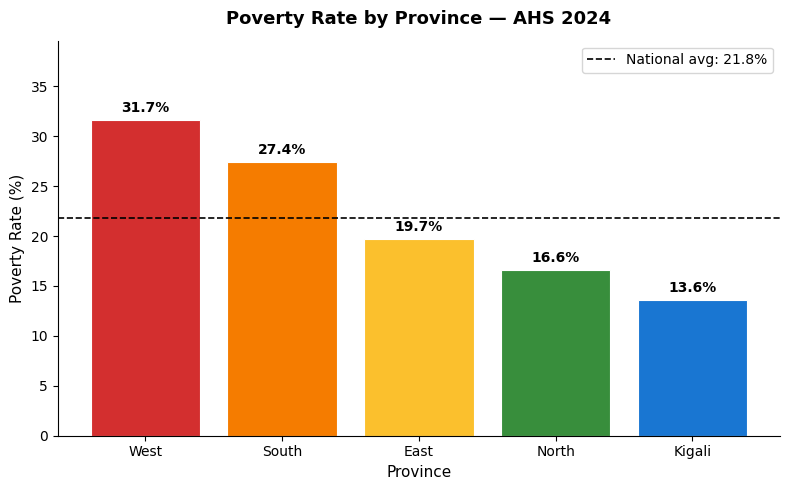

Figure 1 saved ✓


In [9]:
# -------------------------------------------------------
# Figure 1: Poverty rate by province
# -------------------------------------------------------
pov_prov = df.groupby('province_name')['poor'].mean() * 100
pov_prov = pov_prov.reindex(province_order).dropna()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#d32f2f','#f57c00','#fbc02d','#388e3c','#1976d2']
bars = ax.bar(pov_prov.index, pov_prov.values,
              color=colors[:len(pov_prov)], edgecolor='white', linewidth=0.8)
ax.axhline(pov_prov.mean(), color='black', linestyle='--', linewidth=1.2,
           label=f'National avg: {pov_prov.mean():.1f}%')
for bar, val in zip(bars, pov_prov.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Poverty Rate by Province — AHS 2024', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Province', fontsize=11)
ax.set_ylabel('Poverty Rate (%)', fontsize=11)
ax.legend(fontsize=10)
ax.set_ylim(0, pov_prov.max() * 1.25)
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'fig1_poverty_by_province.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved ✓')

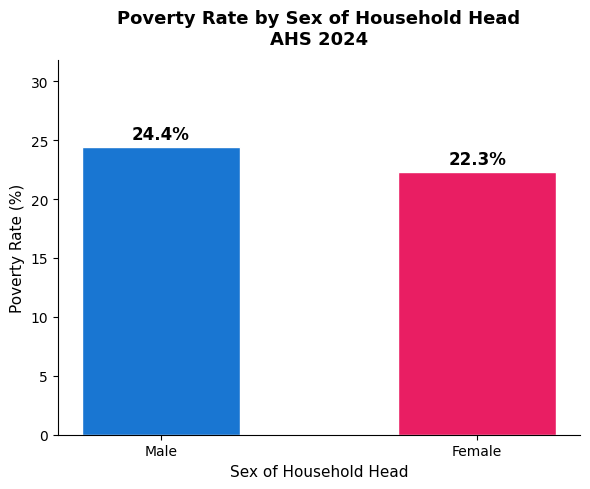

Figure 2 saved ✓


In [10]:
# -------------------------------------------------------
# Figure 2: Poverty rate by sex of HH head
# -------------------------------------------------------
pov_sex = df.groupby('head_sex_label')['poor'].mean() * 100
pov_sex = pov_sex.reindex(['Male', 'Female']).dropna()

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(pov_sex.index, pov_sex.values,
              color=['#1976d2', '#e91e63'], edgecolor='white', width=0.5)
for bar, val in zip(bars, pov_sex.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_title('Poverty Rate by Sex of Household Head\nAHS 2024',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Sex of Household Head', fontsize=11)
ax.set_ylabel('Poverty Rate (%)', fontsize=11)
ax.set_ylim(0, pov_sex.max() * 1.3)
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'fig2_poverty_by_sex.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved ✓')

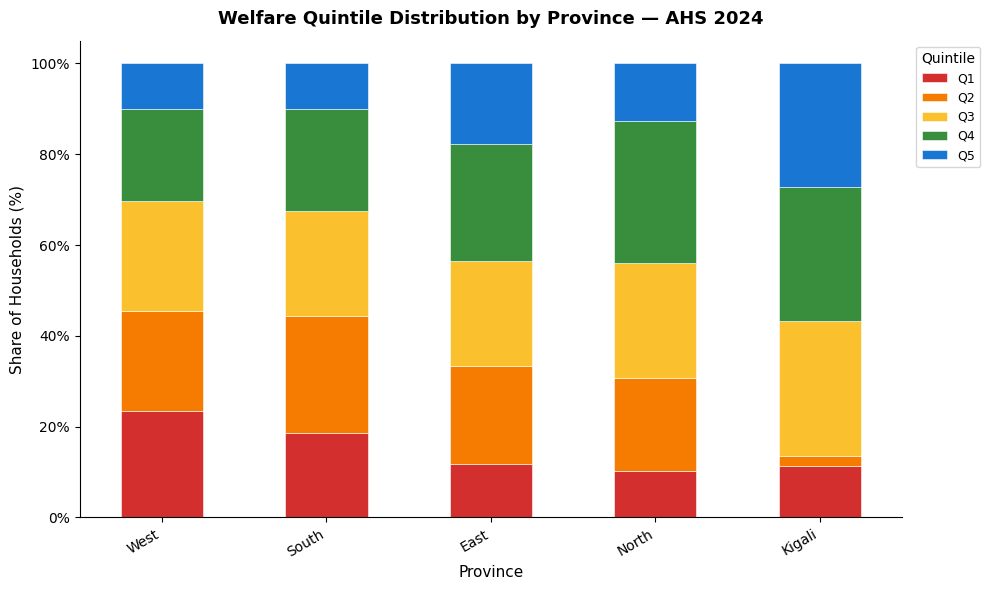

Figure 3 saved ✓


In [11]:
# -------------------------------------------------------
# Figure 3: Welfare quintile distribution by province
# -------------------------------------------------------
df_q = df.dropna(subset=['province_name', 'welfare_quintile'])
quintile_prov = df_q.groupby('province_name')['welfare_quintile'] \
    .value_counts(normalize=True).unstack(fill_value=0) * 100
quintile_prov = quintile_prov.reindex([p for p in province_order if p in quintile_prov.index])

colors_q = ['#d32f2f','#f57c00','#fbc02d','#388e3c','#1976d2']
ax = quintile_prov.plot(kind='bar', stacked=True, figsize=(10, 6),
                         color=colors_q, edgecolor='white', linewidth=0.4)
ax.set_title('Welfare Quintile Distribution by Province — AHS 2024',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Province', fontsize=11)
ax.set_ylabel('Share of Households (%)', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend([f'Q{i}' for i in range(1, 6)], title='Quintile',
          bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'fig3_quintile_by_province.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved ✓')

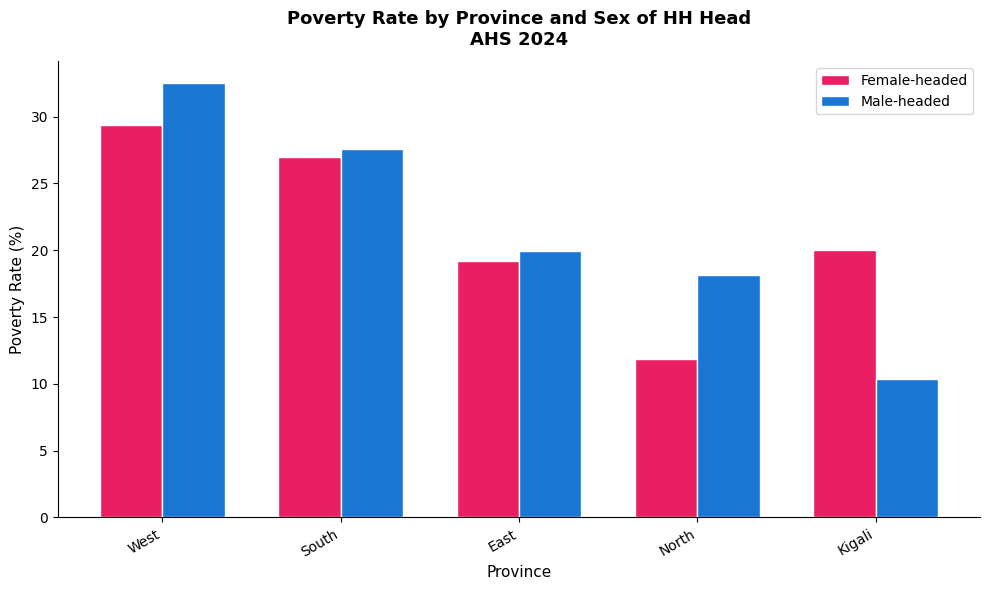

Figure 4 saved ✓


In [12]:
# -------------------------------------------------------
# Figure 4: Poverty rate by province and sex (grouped bar)
# -------------------------------------------------------
pov_ps = df.groupby(['province_name', 'head_sex_label'])['poor'].mean() * 100
pov_ps = pov_ps.unstack()
pov_ps = pov_ps.reindex([p for p in province_order if p in pov_ps.index])

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(pov_ps.index))
width = 0.35

if 'Female' in pov_ps.columns:
    ax.bar(x - width/2, pov_ps['Female'], width,
           label='Female-headed', color='#e91e63', edgecolor='white')
if 'Male' in pov_ps.columns:
    ax.bar(x + width/2, pov_ps['Male'], width,
           label='Male-headed', color='#1976d2', edgecolor='white')

ax.set_title('Poverty Rate by Province and Sex of HH Head\nAHS 2024',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xticks(x)
ax.set_xticklabels(pov_ps.index, rotation=30, ha='right')
ax.set_xlabel('Province', fontsize=11)
ax.set_ylabel('Poverty Rate (%)', fontsize=11)
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'fig4_poverty_province_sex.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved ✓')

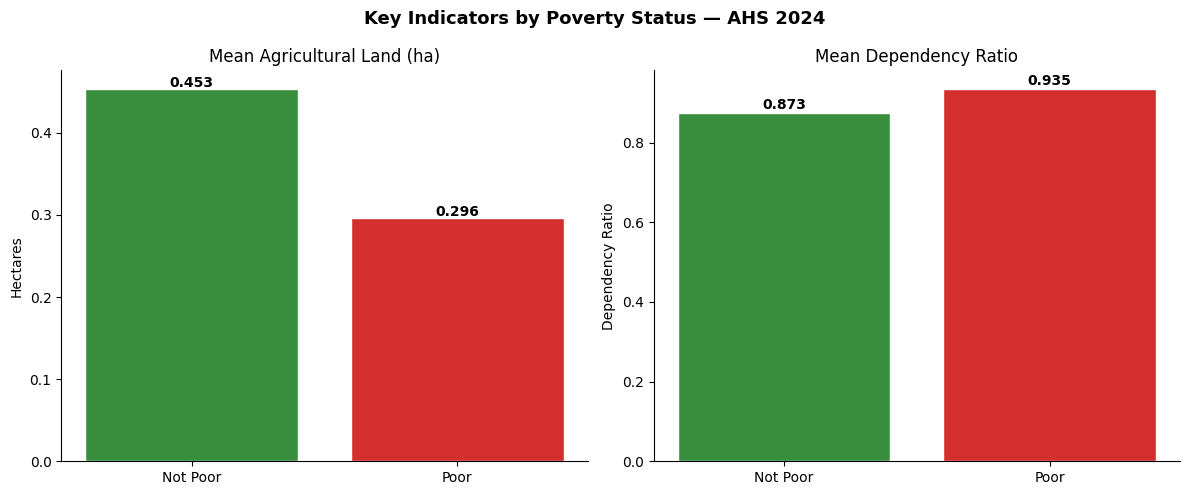

Figure 5 saved ✓


In [13]:
# -------------------------------------------------------
# Figure 5: Mean land and dependency ratio by poverty status
# -------------------------------------------------------
df['poor_label'] = df['poor'].map({0: 'Not Poor', 1: 'Poor'})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Key Indicators by Poverty Status — AHS 2024',
             fontsize=13, fontweight='bold')

# Land by poverty
land_pov = df.groupby('poor_label')['land_ha'].mean().reindex(['Not Poor', 'Poor'])
axes[0].bar(land_pov.index, land_pov.values,
            color=['#388e3c','#d32f2f'], edgecolor='white')
axes[0].set_title('Mean Agricultural Land (ha)')
axes[0].set_ylabel('Hectares')
for i, val in enumerate(land_pov.values):
    if not np.isnan(val):
        axes[0].text(i, val + 0.002, f'{val:.3f}', ha='center', fontweight='bold')

# Dependency ratio by poverty
dep_pov = df.groupby('poor_label')['dep_ratio'].mean().reindex(['Not Poor', 'Poor'])
axes[1].bar(dep_pov.index, dep_pov.values,
            color=['#388e3c','#d32f2f'], edgecolor='white')
axes[1].set_title('Mean Dependency Ratio')
axes[1].set_ylabel('Dependency Ratio')
for i, val in enumerate(dep_pov.values):
    if not np.isnan(val):
        axes[1].text(i, val + 0.01, f'{val:.3f}', ha='center', fontweight='bold')

sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_PATH, 'fig5_land_depratio_by_poverty.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 saved ✓')

## 9. Summary of All Outputs

In [14]:
print('=== ALL OUTPUTS PRODUCED ===')
print('\nTABLES (output/tables/):')
for f in sorted(os.listdir(TABLE_PATH)):
    if f.endswith('.csv'):
        print(f'  ✓ {f}')

print('\nFIGURES (output/figures/):')
for f in sorted(os.listdir(FIGURE_PATH)):
    if f.endswith('.png'):
        print(f'  ✓ {f}')

print('\n✓ Ready for Notebook 4: Regression Analysis')

=== ALL OUTPUTS PRODUCED ===

TABLES (output/tables/):
  ✓ table1_summary_statistics.csv
  ✓ table2_by_province.csv
  ✓ table3_by_sex_of_head.csv
  ✓ table4_poverty_province_sex.csv
  ✓ table5_quintile_by_province.csv
  ✓ table6_ag_activity_poverty.csv

FIGURES (output/figures/):
  ✓ fig1_poverty_by_province.png
  ✓ fig2_poverty_by_sex.png
  ✓ fig3_quintile_by_province.png
  ✓ fig4_poverty_province_sex.png
  ✓ fig5_land_depratio_by_poverty.png
  ✓ poverty_by_province_preview.png
  ✓ variable_distributions.png

✓ Ready for Notebook 4: Regression Analysis


## Key Findings (for Chapter 4)

- **Overall poverty rate:** ~23.87% of agricultural households are poor
- **Provincial variation:** West has the highest poverty rate, Kigali the lowest
- **Gender dimension:** Compare female vs male-headed household poverty rates (Table 3)
- **Welfare distribution:** Uneven across provinces (Table 5, Figure 3)
- **Land and poverty:** Poor households have significantly less agricultural land (Figure 5)
- **Dependency burden:** Poor households carry a higher dependency ratio (Figure 5)

**Next:** `04_regression_analysis.ipynb` — Logit/Probit + marginal effects + OLS